## Setup

In [7]:
import os
import sys
import torch
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from ast import literal_eval
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)

current = os.getcwd()
parent = os.path.dirname(current)
sys.path.append(parent) 

converters = {
    "Word": str, 
    "Phonemes": literal_eval, 
    "No_Stress": literal_eval,
}

from swp.utils.setup import seed_everything, set_device
from swp.utils.models import get_model
from swp.utils.embeddings import create_embeddings_LSTM_hook
from swp.datasets.phonemes import get_phoneme_testloader
from swp.test.repetition import test
from swp.utils.datasets import enrich_for_plotting
from swp.viz.embeddings import dendro_dmatrix
from swp.viz.embeddings import mlem_importance, mlem_phonemes

# Set random seed and device
seed_everything(42)
device = set_device()

# Suppress warnings for nested tensors
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message="The PyTorch API of nested tensors is in prototype stage",
)

import pathlib
figures_path = pathlib.Path("figures")

Using MPS device


## Figures

### Figure 2A-D

In [ ]:
from swp.viz.test.length import plot_length_errors
from swp.viz.test.regressions import regression_plots
from swp.viz.test.position import plot_position_errors_smooth
from swp.viz.test.sonority import plot_sonority_errors

# Load the model
model_name = "Ua_LSTM_h128_l1_v42_d0.0_t0.0_s1"
# weights_path = "weights/1024_75.pth"
# batch_size = 1024
weights_path = "weights/2048_75.pth"
batch_size = 2048

model = get_model(model_name)
model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
model.to(device)

# Evaluate on the Word Feature Evaluation Dataset
wfe_df = pd.read_csv("datasets/wfe.csv", converters=converters, index_col=0)
wfe_loader = get_phoneme_testloader(batch_size=batch_size, dataset_df=wfe_df)
wfe_results, _ = test(
    model=model,
    device=device,
    test_df=wfe_df,
    test_loader=wfe_loader,
)
wfe_results = enrich_for_plotting(wfe_results)
wfe_results.to_csv("data/wfe_enriched.csv")

# Evaluate on the Sonority Sequencing Principle Dataset
ssp_df = pd.read_csv("datasets/ssp.csv", converters=converters, index_col=0)
ssp_loader = get_phoneme_testloader(batch_size=batch_size, dataset_df=ssp_df)
ssp_results, _ = test(
    model=model,
    device=device,
    test_df=ssp_df,
    test_loader=ssp_loader,
)
ssp_results = enrich_for_plotting(ssp_results)
ssp_results.to_csv("data/ssp_enriched.csv")

fig_path = pathlib.Path("figures/control")
fig_path.mkdir(parents=True, exist_ok=True)

plot_length_errors(wfe_results, dir=fig_path, figsize=(7, 6))
regression_plots(wfe_results, path=fig_path, figsize=(7, 6))
plot_position_errors_smooth(wfe_results, dir=fig_path, figsize=(7, 6))
plot_sonority_errors(ssp_results, path=fig_path, figsize=(7, 6))

### Figure 3A-B

In [ ]:
# Load the model
model_name = "Ua_LSTM_h128_l1_v42_d0.0_t0.0_s1"
weights_path = "weights/1024_75.pth"
batch_size = 1024
# weights_path = "weights/2048_75.pth"
# batch_size = 2048

model = get_model(model_name)
model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
model.to(device)

# Create hook to extract embeddings
buffer = {"Hidden": [], "Cell": [], "Out": []}
hook = create_embeddings_LSTM_hook(buffer, store_out=True)
hook_handle = model.encoder.recurrent.register_forward_hook(hook)

# Evaluate on the Single Phonemes Dataset
phonemes_df = pd.read_csv("datasets/phonemes.csv", converters=converters)
phonemes_loader = get_phoneme_testloader(batch_size=batch_size, dataset_df=phonemes_df)
phonemes_results = test(
    model=model,
    device=device,
    test_df=phonemes_df,
    test_loader=phonemes_loader,
)

# Save the embeddings for the Word Feature Evaluation Dataset
embeddings = buffer["Out"][0][np.arange(len(phonemes_df)), 0, :]
print(f"Shape of embeddings: {embeddings.shape}")
np.save("data/phonemes_embeddings.npy", embeddings)
hook_handle.remove()

# # csv_path = "../results/evaluation/Ua_LSTM_h128_l1_v42_d0.0_t0.0_s1/b1024_l0.001_fall_s42_sn_ec/75/control/phonemes.csv"
# # phonemes_df = pd.read_csv(csv_path, index_col=0, converters=converters)

# npy_path = "../results/evaluation/Ua_LSTM_h128_l1_v42_d0.0_t0.0_s1/b1024_l0.001_fall_s42_sn_ec/75/control/phonemes_o.npy"
# embeddings = np.load(npy_path)
# # print(embeddings[:, 2, :])
# embeddings = np.load(npy_path)[np.arange(len(phonemes_df)), 0, :]

# Create a dendrogram and distance matrix for the embeddings
dendro_dmatrix(phonemes_df, embeddings, path=figures_path)

Shape of embeddings: (39, 128)


In [3]:
fig_path = pathlib.Path("figures")

# Separate the phonemes into vowels and consonants
# Drop irrelevant columns for either group
v_df = phonemes_df.query("Type == 'V' and Diphthong == False")
drops = [
    "Symbol", "Type", "Place", "Manner", "Voiced", "No_Stress", "Length", "Prediction"
]
v_df = v_df.drop(columns=drops)
v_emb = embeddings[v_df.index]

c_df = phonemes_df.query("Type == 'C'")
drops = [
    "Symbol", "Type", "Height", "Backness", "Diphthong", "No_Stress", "Length", "Prediction"
]
c_df = c_df.drop(columns=drops)
c_emb = embeddings[c_df.index]

# Calculate feature importances and plot
v_results = mlem_importance(v_df, v_emb)
c_results = mlem_importance(c_df, c_emb)
mlem_phonemes(v_results, c_results, path=fig_path, figsize=(5, 2.5))

### Figure 4

In [ ]:
from swp.test.ablations import ablate
from swp.viz.ablation import ablation_plots, importance_scatter

figures_path = pathlib.Path("figures")

model_name = "Ua_LSTM_h128_l1_v42_d0.0_t0.0_s1"
weights_path = "weights/2048_75.pth"
batch_size = 2048

model = get_model(model_name)
model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
model.to(device)

wfe_df = pd.read_csv("datasets/wfe.csv", converters=converters, index_col=0)
wfe_loader = get_phoneme_testloader(batch_size=batch_size, dataset_df=wfe_df)

_, ablated_results = ablate(
    model=model,  # type: ignore
    device=device,
    test_df=wfe_df,
    test_loader=wfe_loader,
    include_stress=False,
)
# ablated_results = pd.read_csv("data/wfe_ablated.csv", converters=converters)

ablation_plots(
    ablated_results,
    "real_accuracy",
    "pseudo_accuracy",
    "Real (Lexical)",
    "Pseudo (Sublexical)",
    "lex",
    model_dir=figures_path,
)

# ablated_results.to_csv("data/wfe_ablated.csv")

### Figure 5

In [ ]:
from swp.test.ablations import cache_lstm_weights, restore_lstm_weights, ablate_lstm_neuron
from swp.viz.test.length import plot_length_errors
from swp.viz.test.regressions import regression_plots
from swp.viz.test.position import plot_position_errors_smooth
from swp.viz.test.sonority import plot_sonority_errors

# Load the model
model_name = "Ua_LSTM_h128_l1_v42_d0.0_t0.0_s1"
# weights_path = "weights/1024_75.pth"
# batch_size = 1024
weights_path = "weights/2048_75.pth"
batch_size = 2048

model = get_model(model_name)
model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
model.to(device)

wfe_df = pd.read_csv("datasets/wfe.csv", converters=converters, index_col=0)
wfe_loader = get_phoneme_testloader(batch_size=batch_size, dataset_df=wfe_df)

ssp_df = pd.read_csv("datasets/ssp.csv", converters=converters, index_col=0)
ssp_loader = get_phoneme_testloader(batch_size=batch_size, dataset_df=ssp_df)

weights = cache_lstm_weights(model.encoder.recurrent)

for neuron_id in [49, 31]:
    ablate_lstm_neuron(model.encoder.recurrent, neuron_id, 128)

    wfe_results, _ = test(
        model=model,
        device=device,
        test_df=wfe_df,
        test_loader=wfe_loader,
    )
    wfe_results = enrich_for_plotting(wfe_results)
    wfe_results.to_csv(f"data/wfe_{neuron_id}_results.csv")

    ssp_results, _ = test(
        model=model,
        device=device,
        test_df=ssp_df,
        test_loader=ssp_loader,
    )
    ssp_results = enrich_for_plotting(ssp_results)
    ssp_results.to_csv(f"data/ssp_{neuron_id}_results.csv")

    fig_path = pathlib.Path(f"figures/ablations/{neuron_id}")
    fig_path.mkdir(parents=True, exist_ok=True)

    plot_length_errors(wfe_results, dir=fig_path, figsize=(7, 6))
    regression_plots(wfe_results, path=fig_path, figsize=(7, 6))
    plot_position_errors_smooth(wfe_results, dir=fig_path, figsize=(7, 6))
    plot_sonority_errors(ssp_results, path=fig_path, figsize=(7, 6))

    restore_lstm_weights(model.encoder.recurrent, weights)

KeyboardInterrupt: 

### Univariate Feature Importance

     Neuron         Feature  Importance  Spearman  Cluster  cum_importance  \
115      28      Morphology    0.019060  0.825750        0        0.982934   
113      28  Zipf_Frequency    0.120557  0.825750        0        0.963874   
355      88      Morphology    0.000349  0.798462        0        0.894765   
353      88  Zipf_Frequency    0.001593  0.798462        0        0.894415   
354      88      Lexicality    0.011252  0.798462        0        0.892822   
352      88          Length    0.881570  0.798462        0        0.881570   
19        4      Morphology    0.003232  0.797623        0        0.852950   
447     111      Morphology    0.001194  0.846583        0        0.852877   
445     111  Zipf_Frequency    0.007521  0.846583        0        0.851683   
17        4  Zipf_Frequency    0.115469  0.797623        0        0.849718   
243      60      Morphology    0.009934  0.454478        0        0.846366   
446     111      Lexicality    0.019876  0.846583        0      

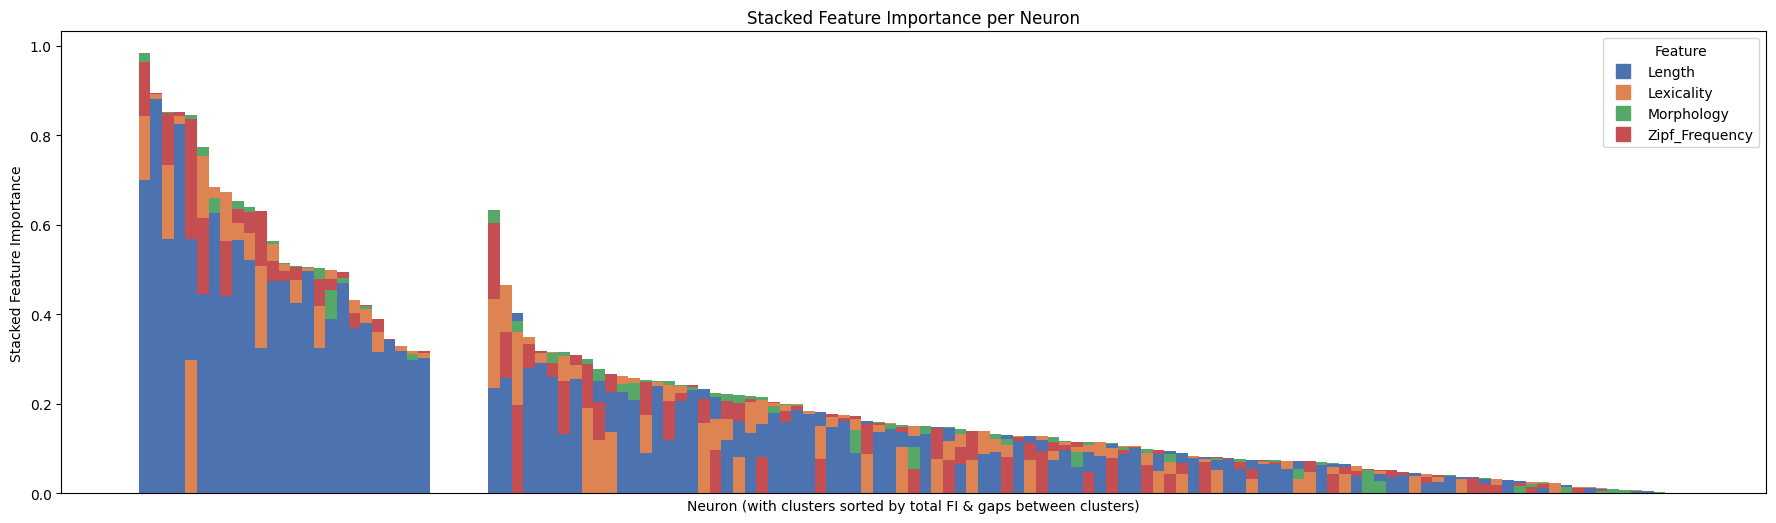

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge, RidgeCV
from scipy.stats import spearmanr

# Load the model
model_name = "Ua_LSTM_h128_l1_v42_d0.0_t0.0_s1"
weights_path = "weights/1024_75.pth"
batch_size = 1024
# weights_path = "weights/2048_75.pth"
# batch_size = 2048
hidden_size = 128

model = get_model(model_name)
model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
model.to(device)

# Create hook to extract embeddings
buffer = {"Hidden": [], "Cell": [], "Out": []}
hook = create_embeddings_LSTM_hook(buffer, store_out=True)
hook_handle = model.encoder.recurrent.register_forward_hook(hook)

# Evaluate on the WFE Dataset
wfe_df = pd.read_csv("datasets/wfe.csv", converters=converters)
wfe_loader = get_phoneme_testloader(batch_size=batch_size, dataset_df=wfe_df)
_, _ = test(
    model=model,
    device=device,
    test_df=wfe_df,
    test_loader=wfe_loader,
)

# Clean the data BEFORE creating features
# Handle NaN values in Zipf_Frequency (set to 0) - fix the problematic line
wfe_df["Zipf_Frequency"] = wfe_df["Zipf_Frequency"].fillna(0)

# Convert categorical features to strings to ensure uniform data types for OneHotEncoder
wfe_df["Lexicality"] = wfe_df["Lexicality"].astype(str)
wfe_df["Morphology"] = wfe_df["Morphology"].astype(str)

# Save the embeddings for the Word Feature Evaluation Dataset
lengths = wfe_df["Length"].to_numpy()
emb = np.vstack(buffer["Out"])
emb = emb[np.arange(len(wfe_df)), lengths, :]
print("Embeddings shape:", emb.shape)

hook_handle.remove()

data = {"Neuron": [], "Feature": [], "Importance": [], "Spearman": []}

continuous = ["Length", "Zipf_Frequency"]
categorical = ["Lexicality", "Morphology"]
features = continuous + categorical

# Check the cleaned data
print("Data types after cleaning:")
print(wfe_df[features].dtypes)
print("Sample values:")
print(wfe_df[features].head())

preprocessor = ColumnTransformer(
    transformers=[
        ("con", StandardScaler(), continuous),
        ("cat", OneHotEncoder(drop="first"), categorical),
    ]
)
pipeline = Pipeline(
        [("preprocessor", preprocessor), ("regressor", LinearRegression())]
    )
X = wfe_df[features].copy()

for idx in range(hidden_size):
    print(f"Calculating importance for neuron {idx+1}...  ", end="\r")
    y = emb[:, idx]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    pipeline.fit(X_train, y_train)
    result = permutation_importance(
        pipeline,
        X_test,
        y_test,
        n_repeats=100,
        random_state=42,
    )
    coefficients = pipeline.named_steps["regressor"].coef_
    importances = result.importances_mean # * np.sign(coefficients)  # type: ignore
    y_pred = pipeline.predict(X_test)
    rho, _ = spearmanr(y_test, y_pred)

    for i, feature in enumerate(features):
        data["Neuron"].append(idx)
        data["Feature"].append(feature)
        data["Importance"].append(importances[i])
        data["Spearman"].append(rho)

df = pd.DataFrame(data)
df.to_csv("data/univariate.csv", index=False)
print("Feature importance analysis completed!")

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def find_best_n_clusters(df, max_clusters=10, seed=42):
    """Finds the optimal number of clusters for the points in `df` using KMeans and the silhouette method.

    Parameters
    ----------
    df : pandas dataframe
        Dataframe of points to cluster
    max_clusters : int, default=6
        Maximum number of clusters
    seed : int, default=0
        Random seed for reproducibility

    Returns
    -------
    best_num_clusters: int
        Optimal number of clusters
    clusters: array
        Cluster labels for each point
    """

    best_num_clusters = 0
    best_silhouette_score = -1
    for num_clusters in range(2, max_clusters + 1):
        kmeans = KMeans(n_clusters=num_clusters, random_state=seed)
        labels = kmeans.fit_predict(df)
        silhouette_avg = silhouette_score(df, labels)

        if silhouette_avg > best_silhouette_score:
            best_silhouette_score = silhouette_avg
            best_num_clusters = num_clusters

    kmeans = KMeans(n_clusters=best_num_clusters, random_state=seed)
    clusters = kmeans.fit_predict(df)

    return best_num_clusters, clusters

copy = df.copy()

copy["Importance"] = np.sign(copy["Importance"]) * np.log1p(np.abs(copy["Importance"]))
# b["Spearman"] = np.clip(b["Spearman"], 0, None)
# b["Importance"] = b["Importance"] / b["Spearman"]

pivot = df.pivot_table(index='Neuron', columns='Feature', values='Importance')
best_num_clusters, clusters = find_best_n_clusters(pivot, max_clusters=8)
print(f"Optimal number of clusters: {best_num_clusters}")

pivot["Cluster"] = clusters
pivot = pivot.reset_index().rename(columns={'index': 'Neuron'})
copy = copy.merge(pivot[["Neuron", "Cluster"]], on="Neuron")

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

df_m = copy.copy()

# ---------------------------
# Step 1: Remove negative importance values by clipping at zero.
df_m['Importance'] = df_m['Importance'].clip(lower=0)
# Optionally, you can also normalize the importance values if needed
# df_m['Importance'] = df_m['Importance'] / df_m["Spearman"].abs().max()

# ---------------------------
# Step 2: Compute cumulative sums per neuron for stacking
# Within each neuron, sort the rows descending by importance (optional, adjust as needed)
df_m = df_m.sort_values(['Neuron', 'Importance'], ascending=[True, False])
df_m['cum_importance'] = df_m.groupby('Neuron')['Importance'].cumsum()
df_m['bottom'] = df_m['cum_importance'] - df_m['Importance']

print(df_m.sort_values("cum_importance", ascending=False).head(30))

# ---------------------------
# Step 3: Compute total importance per neuron.
neuron_totals = df_m.groupby('Neuron')['Importance'].sum().reset_index().rename(
    columns={'Importance': 'total_importance'}
)

# ---------------------------
# Step 4: Get unique neuron-level info (Neuron and Cluster) and merge totals.
neurons = df_m[['Neuron', 'Cluster']].drop_duplicates().reset_index(drop=True)
neurons = neurons.merge(neuron_totals, on="Neuron", how="left")

# ---------------------------
# Step 5: Compute total importance per cluster and sort clusters descending.
cluster_totals = neurons.groupby("Cluster")["total_importance"].sum().reset_index()
cluster_totals = cluster_totals.sort_values("total_importance", ascending=False).reset_index(drop=True)

# Create a mapping from the original Cluster to a new cluster order
cluster_order_map = {old: new for new, old in enumerate(cluster_totals["Cluster"], start=1)}
neurons["new_cluster"] = neurons["Cluster"].map(cluster_order_map)

# ---------------------------
# Step 6: Sort neurons by new cluster order and then by total importance (or neuron id)
neurons = neurons.sort_values(["new_cluster", "total_importance"], ascending=[True, False]).reset_index(drop=True)
neurons["within_cluster_order"] = neurons.groupby("new_cluster").cumcount()

# ---------------------------
# Step 7: Define a custom x-axis (unit_index) with gaps between clusters.
gap_size = 5  # adjust gap size as needed
offset_map = {}
current_offset = 0
for cl in sorted(neurons["new_cluster"].unique()):
    offset_map[cl] = current_offset
    count_in_cluster = neurons[neurons["new_cluster"] == cl].shape[0]
    current_offset += count_in_cluster + gap_size

neurons["unit_index"] = neurons["within_cluster_order"] + neurons["new_cluster"].map(offset_map)

# ---------------------------
# Step 8: Merge the custom unit_index back into the melted DataFrame.
df_m = df_m.merge(neurons[["Neuron", "unit_index"]], on="Neuron", how="left")

# ---------------------------
# Step 9: Plot the stacked bars.
plt.figure(figsize=(22, 6))
ax = plt.gca()

# Use Seaborn's default "deep" palette for our features.
features = sorted(df_m["Feature"].unique())
palette = dict(zip(features, sns.color_palette("deep", len(features))))

# Draw each segment as a bar segment.
for _, row in df_m.iterrows():
    ax.bar(
        row['unit_index'],
        row['Importance'],
        bottom=row['bottom'],
        width=1,
        color=palette.get(row['Feature'], 'gray')
    )

ax.set_xlabel("Neuron (with clusters sorted by total FI & gaps between clusters)")
ax.set_ylabel("Stacked Feature Importance")
ax.set_title("Stacked Feature Importance per Neuron")
plt.xticks([])  # Optionally hide x-tick labels

handles = [
    mlines.Line2D([], [], color=palette[feat], marker='s', linestyle='None', markersize=10, label=feat)
    for feat in features
]
plt.legend(handles=handles, title="Feature", loc='upper right')
plt.show()

### Figure 15

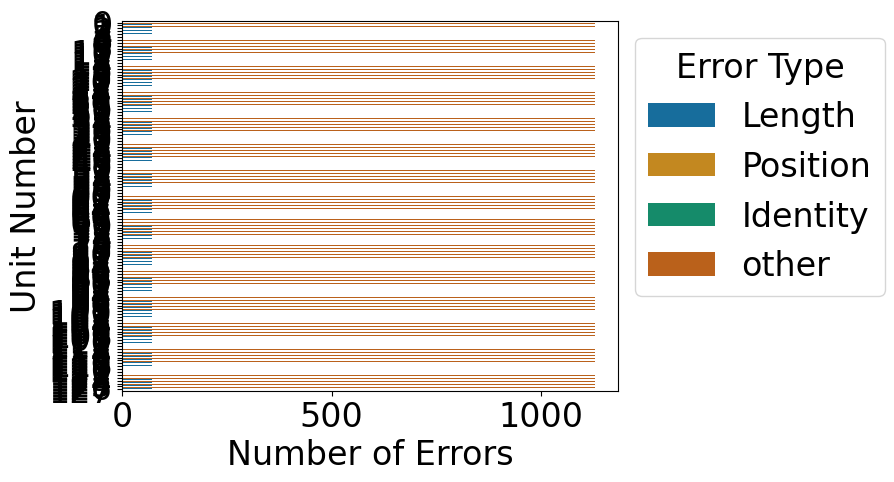

In [12]:
from collections import Counter
import pandas as pd
from ast import literal_eval
import pathlib
import seaborn as sns
from swp.utils.datasets import enrich_for_plotting

def is_early_eos(pred, gt):
    for i in range(len(pred)):
        if pred[i]=="<EOS>":
            return True
        elif pred[i]!=gt[i]:
            return False
    return False

def is_position_error(pred, gt):
    gt_count = Counter(pred)
    pred_count = Counter(gt)
    delta = len(list((gt_count-pred_count).keys())) + len(list((pred_count-gt_count).keys()))
    return delta==0

def is_identity_error(pred, gt):
    for i in range(len(pred)):
        if pred[i] in {"<EOS>", "<SOS>", "<PAD>"}:
            return False
    return True

neurons = range(128)
results = []

# cache the original weights of the LSTM
weights = cache_lstm_weights(model.encoder.recurrent)

# run the ablation test loop for neurons
for neuron in neurons:
    ablate_lstm_neuron(model.encoder.recurrent, neuron, 128)
    wfe_results, _ = test(
        model=model,
        device=device,
        test_df=wfe_df,
        test_loader=wfe_loader,
    )
    wfe_results = enrich_for_plotting(wfe_results)
    results.append(wfe_results)


df_dict = {"Unit Number" : [], "Error Type" : [], "Rate" : [], "Number of Errors" : [], "Unit Name" : []}
errors_dict = {}

for neuron, df in zip(neurons, results):
    df["Error_Rate"] = (df["Edit_Distance"] > 0).astype(int)
    errors = df["Error_Rate"].sum()
    errors_dict[neuron] = errors
    if errors >= 50:
        eos = 0
        permute = 0
        identity = 0
        other = 0

        for (index, row) in df.iterrows():
            pred = row["Prediction"]
            gt = row["No_Stress"]
            is_other = True

            if row["Error_Rate"]==1:
                if is_early_eos(pred, gt):
                    eos += 1
                    is_other = False
                if is_position_error(pred, gt):
                    permute += 1
                    is_other = False
                elif is_identity_error(pred, gt):
                    identity += 1
                    is_other = False
                if is_other:
                    other += 1
        
        for errtype, errcount in [
            ("Length", eos),
            ("Position", permute),
            ("Identity", identity),
            ("other", other)
            ]:
            df_dict["Unit Number"].append(str(neuron))
            df_dict["Error Type"].append(errtype)
            df_dict["Number of Errors"].append(errcount)
            df_dict["Rate"].append(round(errcount/errors*100))
            df_dict["Unit Name"].append(neuron)

error_df = pd.DataFrame(df_dict)
error_df = error_df.iloc[sorted(error_df.index, key=lambda k: errors_dict[error_df.loc[k, "Unit Name"]], reverse=True)]

ax = sns.barplot(error_df, y = "Unit Number", x = "Number of Errors", hue = "Error Type", orient = "h")#, dodge=False)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))